In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

df = pd.read_csv('high_risk_pregnancy_realistic_2000 (1).csv')

In [3]:
import joblib

x_train_smote = joblib.load('x_train_smote.pkl')
y_train_smote = joblib.load('y_train_smote.pkl')
x_test_scaled = joblib.load('x_test_scaled.pkl')
y_test        = joblib.load('y_test.pkl')

In [4]:
dt_model = DecisionTreeClassifier(
    random_state=20
)

In [5]:
dt_model.fit(x_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=20)

In [6]:
dt_pred = dt_model.predict(x_test_scaled)

In [7]:
dt_prob = dt_model.predict_proba(x_test_scaled)[:, 1]
print(dt_prob)

[0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0.
 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1.
 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1.
 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.

In [8]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy, 4))

Decision Tree Accuracy: 0.6742


In [9]:
print("Classification Report\n")

print(classification_report(y_test, dt_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.74      0.79       330
           1       0.22      0.35      0.27        69

    accuracy                           0.67       399
   macro avg       0.53      0.55      0.53       399
weighted avg       0.74      0.67      0.70       399



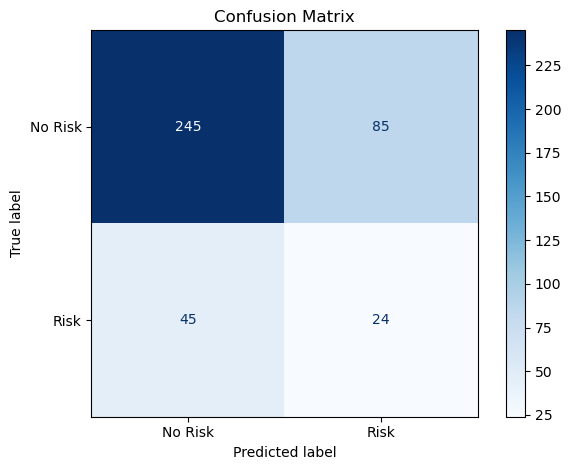

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, dt_pred, display_labels=['No Risk','Risk'], cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

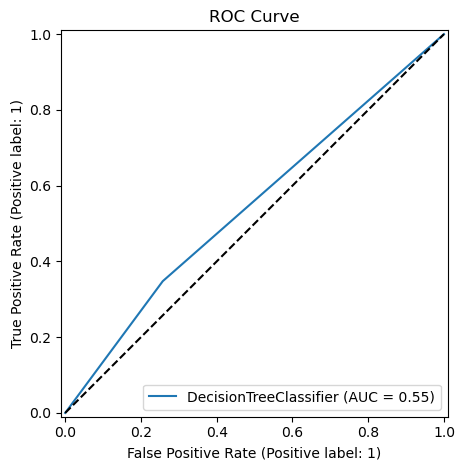

In [11]:
RocCurveDisplay.from_estimator(dt_model, x_test_scaled, y_test)
plt.title('ROC Curve')
plt.plot([0,1],[0,1],'k--')
plt.tight_layout()
plt.show()

In [12]:
print('ROC-AUC Score:', roc_auc_score(y_test, dt_prob).round(4))

ROC-AUC Score: 0.5451


In [13]:
X = df.drop("risk_class", axis=1)
feature_names = X.columns

print("Number of columns in df:", len(df.columns))
print("Number of features in X:", len(X.columns))
print("Number of feature importances:", len(dt_model.feature_importances_))

Number of columns in df: 24
Number of features in X: 23
Number of feature importances: 28


In [14]:
X = df.drop("risk_class", axis=1)
feature_names = X.columns

In [15]:
n_importances = len(dt_model.feature_importances_)

In [16]:
if len(feature_names) == n_importances:
    labels = feature_names
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance = pd.DataFrame({
    "Feature": labels,
    "Importance": dt_model.feature_importances_,
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.to_string(index=False))

   Feature  Importance
 feature_9    0.119294
feature_13    0.095188
feature_12    0.091180
feature_18    0.071823
feature_11    0.064386
 feature_6    0.060518
feature_14    0.057890
feature_10    0.051544
 feature_7    0.050457
 feature_0    0.039321
 feature_8    0.039280
feature_16    0.038144
feature_24    0.037091
feature_15    0.034022
feature_21    0.028225
feature_25    0.022658
feature_19    0.018097
feature_22    0.016533
 feature_1    0.012502
 feature_4    0.010261
feature_23    0.008267
feature_17    0.007891
feature_26    0.007555
 feature_2    0.006843
feature_20    0.006006
 feature_3    0.002953
feature_27    0.002069
 feature_5    0.000000


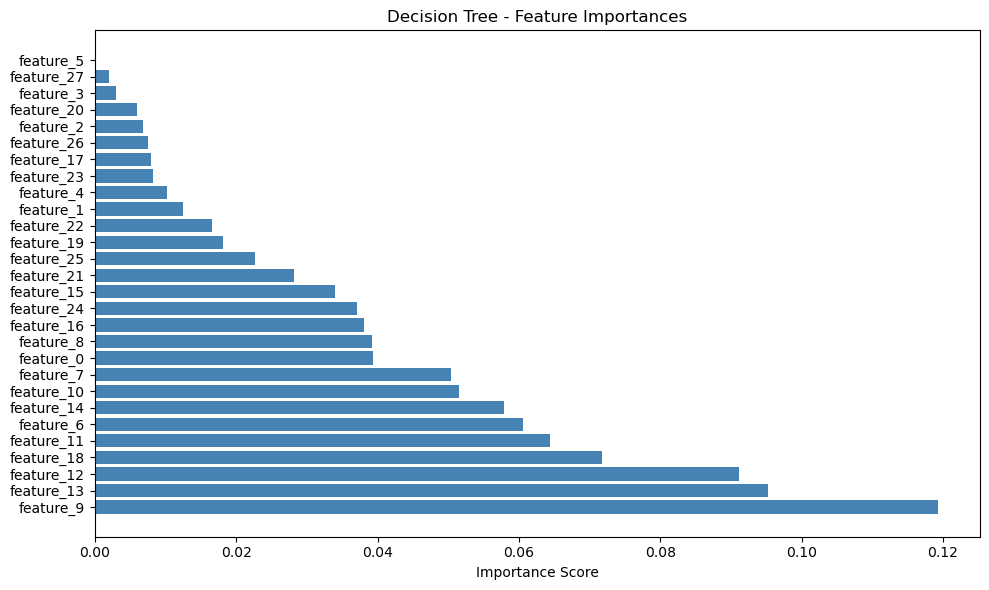

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Decision Tree - Feature Importances")
plt.tight_layout()
plt.show()

In [18]:
train_pred = dt_model.predict(x_train_smote)
print("Train Accuracy:", round(accuracy_score(y_train_smote, train_pred), 4))
print("Test Accuracy :", round(dt_accuracy, 4))

Train Accuracy: 1.0
Test Accuracy : 0.6742


In [19]:
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=20),
                           param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(x_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=20), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_split': [2, 5, 10]},
             scoring='roc_auc')

In [20]:
print("Best Params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 10}


In [21]:
cv_scores = cross_val_score(dt_model, x_train_smote, y_train_smote, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores.round(4))
print("Mean:", cv_scores.mean().round(4), "| Std dev:", cv_scores.std().round(4))

CV ROC-AUC Scores: [0.7295 0.7935 0.7711 0.8407 0.8059]
Mean: 0.7881 | Std dev: 0.037


In [22]:
joblib.dump(dt_model, 'decision_tree_model.pkl')
print("Model saved.")

Model saved.
